In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import torch
from nanodrz.model import DiarizeGPT, Config
from nanodrz.data import libritts_test, artificial_diarisation_sample
from nanodrz.utils import visualise_annotation, play

In [5]:
ckpt = torch.load("/home/harry/0013500.pt")
config = Config(**ckpt["config"])
model:DiarizeGPT = DiarizeGPT.from_pretrained(ckpt).cuda()

8.7599375


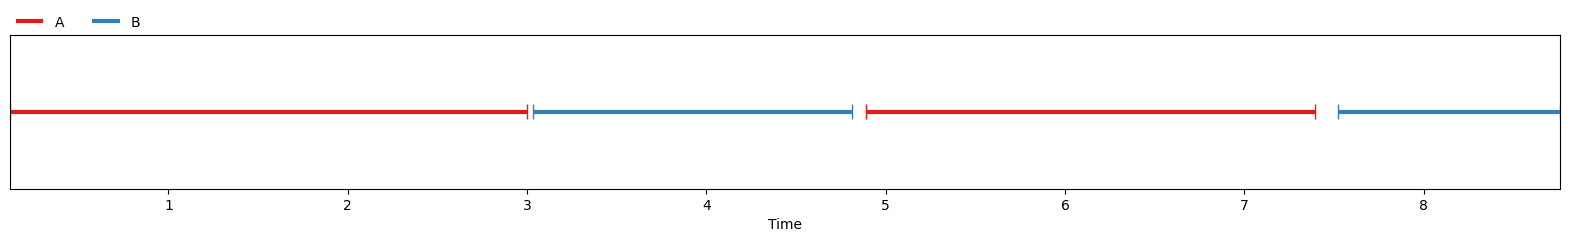

[[0.1165, 2.8811875, 'A'],
 [3.031, 1.7784375, 'B'],
 [4.88925, 2.5036875, 'A'],
 [7.5214375, 1.2385, 'B']]

In [6]:
# Use the same parameters that the model was trained on to generate a sample
audio, labels = artificial_diarisation_sample(libritts_test(), **config.data.model_dump())
print(audio.shape[-1]/16000)
visualise_annotation(labels)
play(audio)
labels

/home/harry/diarisation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[[0.23904383182525635, 3.047808885574341, 'A'], [5.019920349121094, 7.589641571044922, 'A'], [3.047808885574341, 4.9003987312316895, 'B'], [7.828685283660889, 9.501992225646973, 'B'], [5.019920349121094, 7.589641571044922, 'B'], [5.019920349121094, 7.589641571044922, 'A'], [3.167330741882324, 4.9003987312316895, 'A'], [9.621514320373535, 10.458168029785156, 'A'], [3.167330741882324, 4.9601593017578125, 'B'], [5.079681396484375, 7.649402618408203, 'B']]


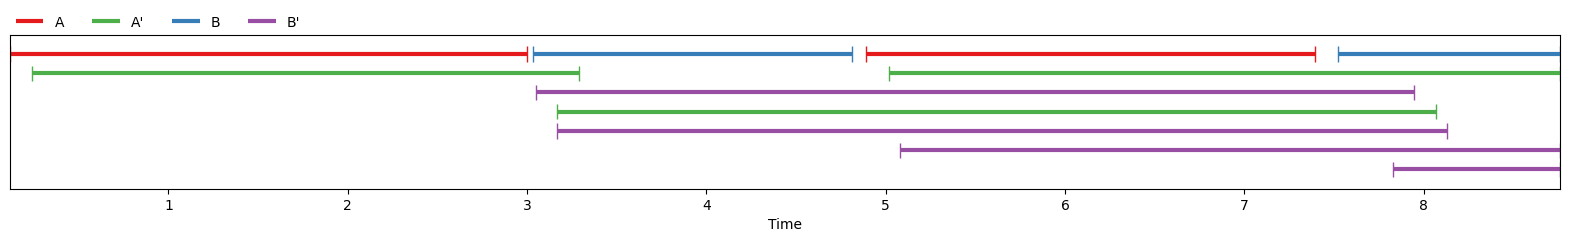

In [7]:
nlabels = model.generate(audio.cuda(), temperature=.3)
print(nlabels)
for l in nlabels:
    l[2] = l[2]+ "'"
visualise_annotation(labels+nlabels)